# 4: Final Results and Explainability

This notebook analyses the final model selected in Notebook 3.

The objective is not to train new models or modify the modelling pipeline. The objective is to interpret and evaluate the already selected Random Forest model.

The notebook focuses on:

- final test-set evaluation;
- risk score interpretation;
- threshold behaviour;
- global explainability with SHAP;
- local explainability for individual examples;
- error analysis;
- final limitations.

The model output is interpreted as a continuous risk score:

`risk_score = P(potentially_unlicensed = 1)`

The binary prediction is obtained using the threshold selected on the validation set in Notebook 3.

In [47]:
import json
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import shap

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve,
    brier_score_loss,
)
from sklearn.calibration import calibration_curve

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 160)

RANDOM_STATE = 42

In [49]:
def find_project_root(start_path=None, project_folder_name="tool"):
    current_path = Path.cwd() if start_path is None else Path(start_path).resolve()

    for path in [current_path] + list(current_path.parents):
        if path.name == project_folder_name:
            return path

    raise RuntimeError(
        f"Could not find project root folder named '{project_folder_name}'. "
        f"Current working directory is: {Path.cwd()}"
    )


PROJECT_DIR = find_project_root()

DATA_DIR = PROJECT_DIR / "data"
GOLD_DIR = DATA_DIR / "gold"

REPORTS_DIR = PROJECT_DIR / "reports"
TABLES_DIR = REPORTS_DIR / "tables"
FIGURES_DIR = REPORTS_DIR / "figures"
MODELS_DIR = PROJECT_DIR / "models"

X_TRAIN_PATH = GOLD_DIR / "X_train.parquet"
Y_TRAIN_PATH = GOLD_DIR / "y_train.parquet"
X_TEST_PATH = GOLD_DIR / "X_test.parquet"
Y_TEST_PATH = GOLD_DIR / "y_test.parquet"
FEATURE_CONFIG_PATH = GOLD_DIR / "feature_config.json"

FINAL_MODEL_PATH = MODELS_DIR / "final_random_forest_pipeline.pkl"
FINAL_MODEL_METADATA_PATH = MODELS_DIR / "final_model_metadata.json"

FINAL_METRICS_PATH = TABLES_DIR / "final_model_metrics.csv"
FINAL_CLASSIFICATION_REPORT_PATH = TABLES_DIR / "final_classification_report.csv"
FINAL_CONFUSION_MATRIX_PATH = TABLES_DIR / "final_confusion_matrix.csv"
FINAL_RISK_SCORES_PATH = TABLES_DIR / "final_risk_scores.csv"
FINAL_RISK_LEVEL_SUMMARY_PATH = TABLES_DIR / "final_risk_level_summary.csv"
FINAL_THRESHOLD_ANALYSIS_PATH = TABLES_DIR / "final_threshold_analysis.csv"
SHAP_GLOBAL_IMPORTANCE_PATH = TABLES_DIR / "shap_global_importance.csv"
SHAP_LOCAL_EXAMPLES_PATH = TABLES_DIR / "shap_local_examples.csv"
ERROR_ANALYSIS_PATH = TABLES_DIR / "final_error_analysis_summary.csv"
LIMITATIONS_TABLE_PATH = TABLES_DIR / "final_limitations_table.csv"
CALIBRATION_SUMMARY_PATH = TABLES_DIR / "appendix_e_calibration_summary.csv"
CALIBRATION_BY_BIN_PATH = TABLES_DIR / "appendix_e_calibration_by_bin.csv"

CONFUSION_MATRIX_FIG_PATH = FIGURES_DIR / "final_confusion_matrix.png"
ROC_CURVE_FIG_PATH = FIGURES_DIR / "final_roc_curve.png"
PR_CURVE_FIG_PATH = FIGURES_DIR / "final_precision_recall_curve.png"
RISK_SCORE_DISTRIBUTION_FIG_PATH = FIGURES_DIR / "final_risk_score_distribution.png"
THRESHOLD_ANALYSIS_FIG_PATH = FIGURES_DIR / "final_threshold_analysis.png"
SHAP_BAR_FIG_PATH = FIGURES_DIR / "shap_summary_bar.png"
SHAP_BEESWARM_FIG_PATH = FIGURES_DIR / "shap_beeswarm.png"
ERROR_ANALYSIS_FIG_PATH = FIGURES_DIR / "final_error_analysis.png"
CALIBRATION_CURVE_FIG_PATH = FIGURES_DIR / "appendix_e_calibration_curve.png"

for directory in [TABLES_DIR, FIGURES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)

PROJECT_DIR: c:\Users\David\Documents\TFG\Fraudulent_property_listing_detection_tool\tool


In [24]:

final_model = joblib.load(FINAL_MODEL_PATH)

with open(FINAL_MODEL_METADATA_PATH, "r", encoding="utf-8") as file:
    final_model_metadata = json.load(file)

with open(FEATURE_CONFIG_PATH, "r", encoding="utf-8") as file:
    feature_config = json.load(file)

X_test = pd.read_parquet(X_TEST_PATH)
y_test = pd.read_parquet(Y_TEST_PATH).iloc[:, 0]
X_train = pd.read_parquet(X_TRAIN_PATH)
y_train = pd.read_parquet(Y_TRAIN_PATH).iloc[:, 0]


numeric_features = feature_config["numeric_features"]
categorical_features = feature_config["categorical_features"]
text_features = feature_config.get("text_features", ["text"])
selected_features = feature_config["selected_features"]
target_col = feature_config["target"]

selected_threshold = final_model_metadata["selected_threshold"]
final_model_name = final_model_metadata["final_model_name"]

print("Final model:", final_model_name)
print("Selected threshold:", selected_threshold)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)



Final model: random_forest
Selected threshold: 0.37000000000000005
X_test shape: (3055, 24)
y_test shape: (3055,)


In [25]:
risk_score = final_model.predict_proba(X_test)[:, 1]
binary_prediction = (risk_score >= selected_threshold).astype(int)

prediction_df = X_test.copy()
prediction_df["true_label"] = y_test.values
prediction_df["risk_score"] = risk_score
prediction_df["selected_threshold"] = selected_threshold
prediction_df["binary_prediction"] = binary_prediction

display(prediction_df.head())

prediction_df.to_csv(FINAL_RISK_SCORES_PATH, index=False)

print("Saved:", FINAL_RISK_SCORES_PATH)

,log_price,minimum_nights,availability_365,number_of_reviews,reviews_per_month,number_of_reviews_ltm,calculated_host_listings_count,word_count,uppercase_ratio,digit_count,exclamation_count,distance_to_nearest_license_m,nearest_license_places,licenses_within_100m,licenses_within_250m,licenses_within_500m,has_license_within_100m,has_license_within_250m,has_license_within_500m,license_density_250m_per_km2,license_density_500m_per_km2,property_type,neighbourhood,text,true_label,risk_score,selected_threshold,binary_prediction
0,4.174387,32,264,11,0.32,2,14,6,0.162791,0,0,49.948822,4.0,3.0,30.0,155.0,1.0,1.0,1.0,152.788745,197.352129,Entire home/apt,el Barri Gòtic,"Great classic&renovated, TOP centrally located APT",0,0.470,0.37,1
1,4.094345,1,33,12,0.21,2,17,6,0.029412,0,0,38.828451,13.0,6.0,49.0,175.0,1.0,1.0,1.0,249.554951,222.816920,Entire home/apt,el Barri Gòtic,Penthouse with therrace and double room,0,0.060,0.37,0
2,4.276666,32,336,0,0.00,0,44,6,0.080000,0,0,48.170319,5.0,2.0,11.0,42.0,1.0,1.0,1.0,56.022540,53.476061,Entire home/apt,el Putxet i el Farró,Bright & comfy apartment in Bcn,1,0.665,0.37,1
3,5.918894,1,326,5,0.10,1,15,7,0.764706,18,0,29.272964,5.0,22.0,161.0,404.0,1.0,1.0,1.0,819.966267,514.388776,Entire home/apt,la Vila de Gràcia,HUTB-000578 · HUTB-000578 · HUTB-000578 · Suite...,0,0.090,0.37,0
4,3.688879,31,365,0,0.00,0,1,6,0.093023,0,0,39.115694,5.0,9.0,99.0,369.0,1.0,1.0,1.0,504.202860,469.825392,Private room,la Vila de Gràcia,"Habitación individual en Gràcia, Barcelona Centro",1,0.745,0.37,1


Saved: c:\Users\David\Documents\TFG\Fraudulent_property_listing_detection_tool\tool\reports\tables\final_risk_scores.csv


## Final model metrics

The following metrics evaluate the final Random Forest model on the test set using the threshold selected on the validation set.

The metrics are interpreted as follows:

- **Accuracy**: overall proportion of correct predictions.
- **Precision**: among listings predicted as `potentially_unlicensed`, how many are actually positive.
- **Recall**: among all real `potentially_unlicensed` listings, how many the model detects.
- **F1-score**: balance between precision and recall.
- **ROC-AUC**: ranking quality across all possible thresholds.
- **PR-AUC**: precision-recall ranking quality for the positive class.

In [26]:
final_metrics = {
    "model": final_model_name,
    "selected_threshold": selected_threshold,
    "accuracy": accuracy_score(y_test, binary_prediction),
    "precision": precision_score(y_test, binary_prediction, zero_division=0),
    "recall": recall_score(y_test, binary_prediction, zero_division=0),
    "f1": f1_score(y_test, binary_prediction, zero_division=0),
    "roc_auc": roc_auc_score(y_test, risk_score),
    "pr_auc": average_precision_score(y_test, risk_score),
}

final_metrics_df = pd.DataFrame([final_metrics])

display(final_metrics_df)

final_metrics_df.to_csv(FINAL_METRICS_PATH, index=False)

print("Saved:", FINAL_METRICS_PATH)

,model,selected_threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,random_forest,0.37,0.875941,0.68427,0.861386,0.76268,0.935116,0.807779


Saved: c:\Users\David\Documents\TFG\Fraudulent_property_listing_detection_tool\tool\reports\tables\final_model_metrics.csv


## Classification report

In [27]:
classification_report_dict = classification_report(
    y_test,
    binary_prediction,
    target_names=["declared_license", "potentially_unlicensed"],
    output_dict=True,
    zero_division=0,
)

classification_report_df = pd.DataFrame(classification_report_dict).transpose()

display(classification_report_df)

classification_report_df.to_csv(FINAL_CLASSIFICATION_REPORT_PATH)

print("Saved:", FINAL_CLASSIFICATION_REPORT_PATH)

,precision,recall,f1-score,support
declared_license,0.954734,0.880324,0.916020,2348.000000
potentially_unlicensed,0.684270,0.861386,0.762680,707.000000
accuracy,0.875941,0.875941,0.875941,0.875941
macro avg,0.819502,0.870855,0.839350,3055.000000
weighted avg,0.892142,0.875941,0.880534,3055.000000


Saved: c:\Users\David\Documents\TFG\Fraudulent_property_listing_detection_tool\tool\reports\tables\final_classification_report.csv


## Confusion matrix

The confusion matrix helps interpret the types of errors made by the model.

- False positives: listings predicted as `potentially_unlicensed` although they declare a licence.
- False negatives: listings without a declared licence that the model does not detect.

These errors are important because the model is intended as a risk-support system, not an automatic legal decision system.

,pred_declared_license,pred_potentially_unlicensed
true_declared_license,2067,281
true_potentially_unlicensed,98,609


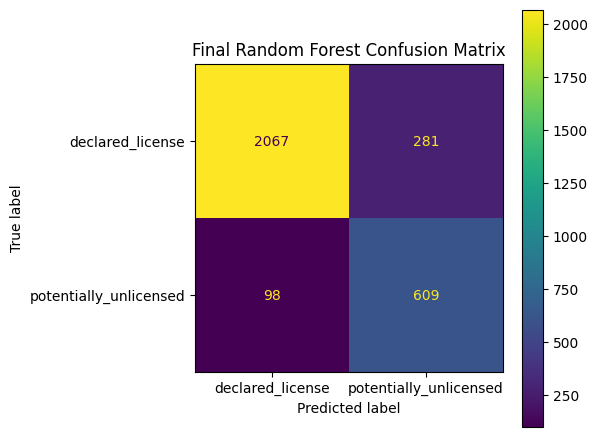

Saved: c:\Users\David\Documents\TFG\Fraudulent_property_listing_detection_tool\tool\reports\tables\final_confusion_matrix.csv
Saved: c:\Users\David\Documents\TFG\Fraudulent_property_listing_detection_tool\tool\reports\figures\final_confusion_matrix.png


In [28]:
cm = confusion_matrix(y_test, binary_prediction)

confusion_matrix_df = pd.DataFrame(
    cm,
    index=["true_declared_license", "true_potentially_unlicensed"],
    columns=["pred_declared_license", "pred_potentially_unlicensed"],
)

display(confusion_matrix_df)

confusion_matrix_df.to_csv(FINAL_CONFUSION_MATRIX_PATH)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["declared_license", "potentially_unlicensed"],
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, values_format="d")
plt.title("Final Random Forest Confusion Matrix")
plt.tight_layout()
plt.savefig(CONFUSION_MATRIX_FIG_PATH, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", FINAL_CONFUSION_MATRIX_PATH)
print("Saved:", CONFUSION_MATRIX_FIG_PATH)

## ROC and Precision-Recall curves

The ROC curve evaluates how well the model separates both classes across all thresholds.

The Precision-Recall curve is especially relevant because the project focuses on the positive class: `potentially_unlicensed`.

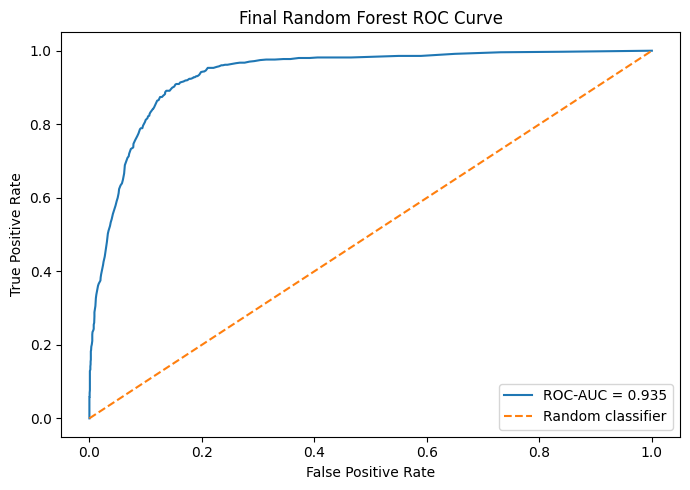

Saved: c:\Users\David\Documents\TFG\Fraudulent_property_listing_detection_tool\tool\reports\figures\final_roc_curve.png


In [29]:
fpr, tpr, roc_thresholds = roc_curve(y_test, risk_score)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {final_metrics['roc_auc']:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Final Random Forest ROC Curve")
plt.legend()
plt.tight_layout()
plt.savefig(ROC_CURVE_FIG_PATH, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", ROC_CURVE_FIG_PATH)

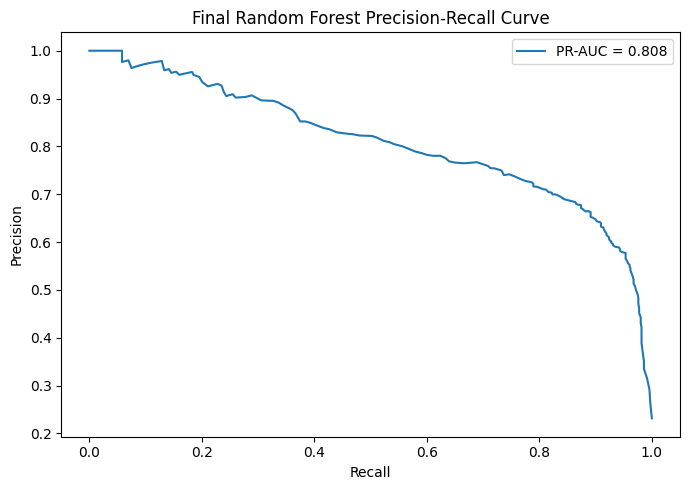

Saved: c:\Users\David\Documents\TFG\Fraudulent_property_listing_detection_tool\tool\reports\figures\final_precision_recall_curve.png


In [30]:
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(
    y_test,
    risk_score,
)

plt.figure(figsize=(7, 5))
plt.plot(recall_curve, precision_curve, label=f"PR-AUC = {final_metrics['pr_auc']:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Final Random Forest Precision-Recall Curve")
plt.legend()
plt.tight_layout()
plt.savefig(PR_CURVE_FIG_PATH, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", PR_CURVE_FIG_PATH)

## Risk score analysis

The model is not interpreted only as a binary classifier. Its main output is a continuous `risk_score`.

The risk score can support prioritisation: higher scores indicate listings with patterns more similar to the `potentially_unlicensed` class.

The score does not prove illegal behaviour.

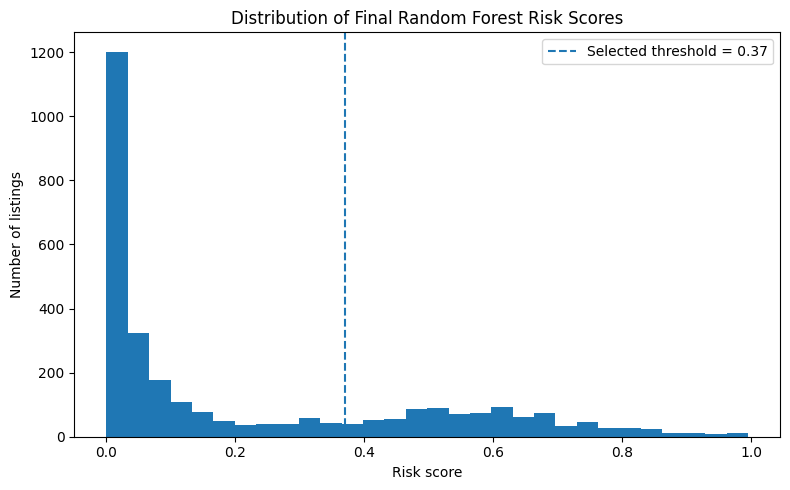

Saved: c:\Users\David\Documents\TFG\Fraudulent_property_listing_detection_tool\tool\reports\figures\final_risk_score_distribution.png


In [31]:
plt.figure(figsize=(8, 5))
plt.hist(risk_score, bins=30)
plt.axvline(
    selected_threshold,
    linestyle="--",
    label=f"Selected threshold = {selected_threshold:.2f}",
)
plt.xlabel("Risk score")
plt.ylabel("Number of listings")
plt.title("Distribution of Final Random Forest Risk Scores")
plt.legend()
plt.tight_layout()
plt.savefig(RISK_SCORE_DISTRIBUTION_FIG_PATH, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", RISK_SCORE_DISTRIBUTION_FIG_PATH)

In [32]:
prediction_df["risk_level"] = pd.cut(
    prediction_df["risk_score"],
    bins=[-0.001, 0.33, 0.66, 1.0],
    labels=["low", "medium", "high"],
)

risk_level_summary = (
    prediction_df
    .groupby("risk_level", observed=False)
    .agg(
        count=("risk_score", "size"),
        mean_risk_score=("risk_score", "mean"),
        positive_rate=("true_label", "mean"),
    )
    .reset_index()
)

risk_level_summary["proportion"] = (
    risk_level_summary["count"] / risk_level_summary["count"].sum()
)

display(risk_level_summary)

risk_level_summary.to_csv(FINAL_RISK_LEVEL_SUMMARY_PATH, index=False)

print("Saved:", FINAL_RISK_LEVEL_SUMMARY_PATH)

,risk_level,count,mean_risk_score,positive_rate,proportion
0,low,2112,0.057476,0.037879,0.691326
1,medium,666,0.515368,0.573574,0.218003
2,high,277,0.773610,0.884477,0.090671


Saved: c:\Users\David\Documents\TFG\Fraudulent_property_listing_detection_tool\tool\reports\tables\final_risk_level_summary.csv


,model,brier_score,interpretation
0,random_forest,0.085152,Lower values indicate better calibration. The score is mainly used for ranking and prioritisation.


Saved: c:\Users\David\Documents\TFG\Fraudulent_property_listing_detection_tool\tool\reports\tables\appendix_e_calibration_summary.csv


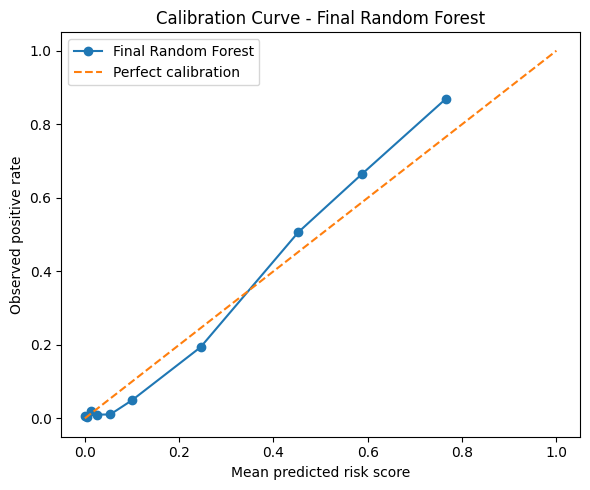

Saved: c:\Users\David\Documents\TFG\Fraudulent_property_listing_detection_tool\tool\reports\figures\appendix_e_calibration_curve.png


,risk_bin,n,mean_predicted_risk,observed_positive_rate,absolute_calibration_error
0,"(-0.001, 0.005]",635,0.002008,0.004724,0.002717
1,"(0.005, 0.015]",339,0.012153,0.020649,0.008496
2,"(0.015, 0.035]",295,0.026780,0.010169,0.016610
3,"(0.035, 0.07]",285,0.053772,0.010526,0.043246
4,"(0.07, 0.145]",283,0.100265,0.049470,0.050795
5,"(0.145, 0.355]",305,0.245279,0.193443,0.051836
6,"(0.355, 0.52]",314,0.452707,0.506369,0.053662
7,"(0.52, 0.65]",301,0.587525,0.664452,0.076927
8,"(0.65, 0.995]",298,0.765487,0.869128,0.103641


Saved: c:\Users\David\Documents\TFG\Fraudulent_property_listing_detection_tool\tool\reports\tables\appendix_e_calibration_by_bin.csv


In [50]:
brier_score = brier_score_loss(y_test, risk_score)

calibration_summary_df = pd.DataFrame(
    {
        "model": [final_model_name],
        "brier_score": [brier_score],
        "interpretation": [
            "Lower values indicate better calibration. The score is mainly used for ranking and prioritisation."
        ],
    }
)

display(calibration_summary_df)

calibration_summary_df.to_csv(
    CALIBRATION_SUMMARY_PATH,
    index=False,
)

print("Saved:", CALIBRATION_SUMMARY_PATH)

# ------------------------------------------------------------
# Calibration curve
# ------------------------------------------------------------

prob_true, prob_pred = calibration_curve(
    y_test,
    risk_score,
    n_bins=10,
    strategy="quantile",
)

plt.figure(figsize=(6, 5))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="Final Random Forest",
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration",
)

plt.xlabel("Mean predicted risk score")
plt.ylabel("Observed positive rate")
plt.title("Calibration Curve - Final Random Forest")
plt.legend()
plt.tight_layout()

plt.savefig(
    CALIBRATION_CURVE_FIG_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", CALIBRATION_CURVE_FIG_PATH)

# ------------------------------------------------------------
# Calibration table by predicted-risk bins
# ------------------------------------------------------------

calibration_df = pd.DataFrame(
    {
        "true_label": y_test.values,
        "risk_score": risk_score,
    }
)

calibration_df["risk_bin"] = pd.qcut(
    calibration_df["risk_score"],
    q=10,
    duplicates="drop",
)

calibration_by_bin_df = (
    calibration_df
    .groupby("risk_bin", observed=False)
    .agg(
        n=("true_label", "size"),
        mean_predicted_risk=("risk_score", "mean"),
        observed_positive_rate=("true_label", "mean"),
    )
    .reset_index()
)

calibration_by_bin_df["absolute_calibration_error"] = (
    calibration_by_bin_df["mean_predicted_risk"]
    - calibration_by_bin_df["observed_positive_rate"]
).abs()

display(calibration_by_bin_df)

calibration_by_bin_df.to_csv(
    CALIBRATION_BY_BIN_PATH,
    index=False,
)

print("Saved:", CALIBRATION_BY_BIN_PATH)

## Final threshold behaviour

The threshold was already selected in Notebook 3 using the validation set.

Here, the threshold analysis is used only to interpret the behaviour of the final model on the test set. It shows how precision, recall and F1-score change when the operating threshold changes.

This is useful because the model is intended as a configurable risk-scoring support tool.

In [33]:
thresholds = np.arange(0.05, 0.96, 0.01)

threshold_rows = []

for threshold in thresholds:
    y_pred_threshold = (risk_score >= threshold).astype(int)

    threshold_rows.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, y_pred_threshold),
        "precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "recall": recall_score(y_test, y_pred_threshold, zero_division=0),
        "f1": f1_score(y_test, y_pred_threshold, zero_division=0),
        "predicted_positive_rate": y_pred_threshold.mean(),
    })

threshold_analysis = pd.DataFrame(threshold_rows)

display(threshold_analysis.head())

threshold_analysis.to_csv(FINAL_THRESHOLD_ANALYSIS_PATH, index=False)

print("Saved:", FINAL_THRESHOLD_ANALYSIS_PATH)

,threshold,accuracy,precision,recall,f1,predicted_positive_rate
0,0.05,0.667758,0.409198,0.981612,0.577611,0.555155
1,0.06,0.709329,0.442246,0.980198,0.609499,0.512930
2,0.07,0.720131,0.451634,0.977369,0.617792,0.500818
3,0.08,0.752864,0.483193,0.975955,0.646370,0.467430
4,0.09,0.768249,0.499636,0.971711,0.659942,0.450082


Saved: c:\Users\David\Documents\TFG\Fraudulent_property_listing_detection_tool\tool\reports\tables\final_threshold_analysis.csv


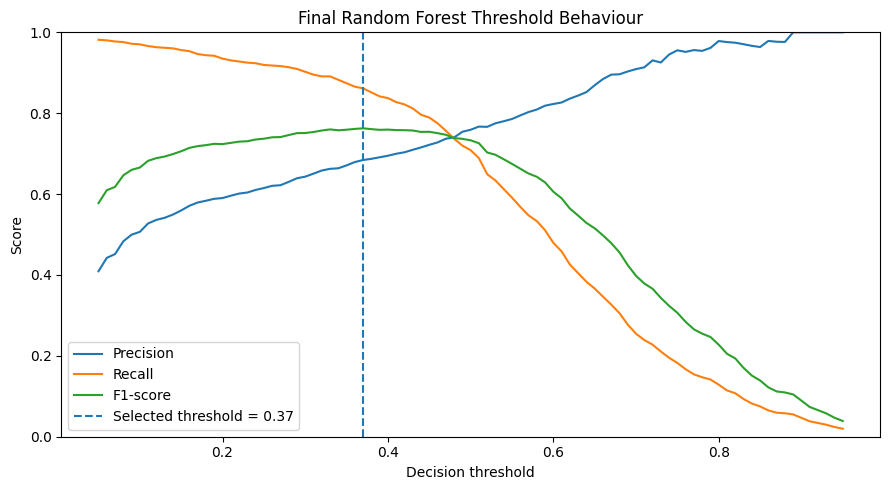

Saved: c:\Users\David\Documents\TFG\Fraudulent_property_listing_detection_tool\tool\reports\figures\final_threshold_analysis.png


In [34]:
plt.figure(figsize=(9, 5))

plt.plot(threshold_analysis["threshold"], threshold_analysis["precision"], label="Precision")
plt.plot(threshold_analysis["threshold"], threshold_analysis["recall"], label="Recall")
plt.plot(threshold_analysis["threshold"], threshold_analysis["f1"], label="F1-score")

plt.axvline(
    selected_threshold,
    linestyle="--",
    label=f"Selected threshold = {selected_threshold:.2f}",
)

plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.title("Final Random Forest Threshold Behaviour")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.savefig(THRESHOLD_ANALYSIS_FIG_PATH, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", THRESHOLD_ANALYSIS_FIG_PATH)

## SHAP explainability

SHAP is used to explain the final Random Forest model.

SHAP values estimate how each feature contributes to increasing or decreasing the model output for a given prediction.

Important limitation:

> SHAP explains the behaviour of the model. It does not prove real-world causality.

Since the Random Forest is inside a scikit-learn pipeline, the test data is first transformed using the fitted preprocessor. SHAP is then applied to the fitted Random Forest estimator.

In [35]:
preprocessor = final_model.named_steps["preprocessor"]
rf_estimator = final_model.named_steps["model"]

X_test_transformed = preprocessor.transform(X_test)

if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

feature_names = preprocessor.get_feature_names_out()

X_test_transformed_df = pd.DataFrame(
    X_test_transformed,
    columns=feature_names,
)

# Use a sample for SHAP to keep the notebook fast and stable.
SHAP_SAMPLE_SIZE = min(1000, len(X_test_transformed_df))

X_shap = X_test_transformed_df.sample(
    n=SHAP_SAMPLE_SIZE,
    random_state=RANDOM_STATE,
)

print("Transformed X_test shape:", X_test_transformed_df.shape)
print("SHAP sample shape:", X_shap.shape)

display(X_shap.head())

Transformed X_test shape: (3055, 96)
SHAP sample shape: (1000, 96)


,num__log_price,num__minimum_nights,num__availability_365,num__number_of_reviews,num__reviews_per_month,num__number_of_reviews_ltm,num__calculated_host_listings_count,num__word_count,num__uppercase_ratio,num__digit_count,num__exclamation_count,num__distance_to_nearest_license_m,num__nearest_license_places,num__licenses_within_100m,num__licenses_within_250m,num__licenses_within_500m,num__has_license_within_100m,num__has_license_within_250m,num__has_license_within_500m,num__license_density_250m_per_km2,num__license_density_500m_per_km2,cat__property_type_Entire home/apt,cat__property_type_Hotel room,cat__property_type_Private room,cat__property_type_Shared room,cat__neighbourhood_Can Baró,cat__neighbourhood_Can Peguera,cat__neighbourhood_Canyelles,cat__neighbourhood_Ciutat Meridiana,cat__neighbourhood_Diagonal Mar i el Front Marítim del Poblenou,cat__neighbourhood_Horta,cat__neighbourhood_Hostafrancs,cat__neighbourhood_Montbau,cat__neighbourhood_Navas,cat__neighbourhood_Pedralbes,cat__neighbourhood_Porta,cat__neighbourhood_Provençals del Poblenou,cat__neighbourhood_Sant Andreu,cat__neighbourhood_Sant Antoni,cat__neighbourhood_Sant Genís dels Agudells,cat__neighbourhood_Sant Gervasi - Galvany,cat__neighbourhood_Sant Gervasi - la Bonanova,cat__neighbourhood_Sant Martí de Provençals,"cat__neighbourhood_Sant Pere, Santa Caterina i la Ribera",cat__neighbourhood_Sants,cat__neighbourhood_Sants - Badal,cat__neighbourhood_Sarrià,cat__neighbourhood_Torre Baró,cat__neighbourhood_Vallcarca i els Penitents,"cat__neighbourhood_Vallvidrera, el Tibidabo i les Planes",cat__neighbourhood_Verdun,cat__neighbourhood_Vilapicina i la Torre Llobeta,cat__neighbourhood_el Baix Guinardó,cat__neighbourhood_el Barri Gòtic,cat__neighbourhood_el Besòs i el Maresme,cat__neighbourhood_el Bon Pastor,cat__neighbourhood_el Camp d'en Grassot i Gràcia Nova,cat__neighbourhood_el Camp de l'Arpa del Clot,cat__neighbourhood_el Carmel,cat__neighbourhood_el Clot,cat__neighbourhood_el Coll,cat__neighbourhood_el Congrés i els Indians,cat__neighbourhood_el Fort Pienc,cat__neighbourhood_el Guinardó,cat__neighbourhood_el Parc i la Llacuna del Poblenou,cat__neighbourhood_el Poble Sec,cat__neighbourhood_el Poblenou,cat__neighbourhood_el Putxet i el Farró,cat__neighbourhood_el Raval,cat__neighbourhood_el Turó de la Peira,cat__neighbourhood_l'Antiga Esquerra de l'Eixample,cat__neighbourhood_la Barceloneta,cat__neighbourhood_la Bordeta,cat__neighbourhood_la Clota,cat__neighbourhood_la Dreta de l'Eixample,cat__neighbourhood_la Font d'en Fargues,cat__neighbourhood_la Font de la Guatlla,cat__neighbourhood_la Guineueta,cat__neighbourhood_la Marina de Port,cat__neighbourhood_la Marina del Prat Vermell,cat__neighbourhood_la Maternitat i Sant Ramon,cat__neighbourhood_la Nova Esquerra de l'Eixample,cat__neighbourhood_la Prosperitat,cat__neighbourhood_la Sagrada Família,cat__neighbourhood_la Sagrera,cat__neighbourhood_la Salut,cat__neighbourhood_la Teixonera,cat__neighbourhood_la Trinitat Nova,cat__neighbourhood_la Trinitat Vella,cat__neighbourhood_la Vall d'Hebron,cat__neighbourhood_la Verneda i la Pau,cat__neighbourhood_la Vila Olímpica del Poblenou,cat__neighbourhood_la Vila de Gràcia,cat__neighbourhood_les Corts,cat__neighbourhood_les Roquetes,cat__neighbourhood_les Tres Torres
2374,0.023507,-0.588378,-2.005316,-0.460958,-0.311010,-0.275369,-0.026524,0.072427,0.049339,0.201407,-0.20136,0.202649,0.257915,0.113153,0.014924,-0.265206,0.322826,0.109199,0.044361,0.014924,-0.265206,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
63,0.407839,-0.588378,0.887189,0.374062,-0.113080,0.204152,-0.514620,1.043594,-0.634879,-0.544410,-0.20136,-0.703644,-0.611339,-0.105126,-0.653474,-1.090787,0.322826,0.109199,0.044361,-0.653474,-1.090787,1.0,0.0,0.0,0.0,

In [36]:
explainer = shap.TreeExplainer(rf_estimator)

shap_values_raw = explainer.shap_values(X_shap)

# Compatibility with different SHAP versions:
# - Some versions return a list: [class_0_values, class_1_values]
# - Some return an array with shape (n_samples, n_features, n_classes)
if isinstance(shap_values_raw, list):
    shap_values_positive = shap_values_raw[1]
elif isinstance(shap_values_raw, np.ndarray) and shap_values_raw.ndim == 3:
    shap_values_positive = shap_values_raw[:, :, 1]
else:
    shap_values_positive = shap_values_raw

print("SHAP values shape:", shap_values_positive.shape)

SHAP values shape: (1000, 96)


## SHAP global importance

The SHAP global importance table ranks features by their mean absolute SHAP value.

Higher values mean that the feature has a stronger average influence on the model output.

In [37]:
shap_global_importance = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": np.abs(shap_values_positive).mean(axis=0),
})

shap_global_importance = (
    shap_global_importance
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

display(shap_global_importance.head(30))

shap_global_importance.to_csv(SHAP_GLOBAL_IMPORTANCE_PATH, index=False)

print("Saved:", SHAP_GLOBAL_IMPORTANCE_PATH)

,feature,mean_abs_shap
0,num__minimum_nights,0.147121
1,num__reviews_per_month,0.072899
2,num__log_price,0.045850
3,num__number_of_reviews_ltm,0.042073
4,num__number_of_reviews,0.029688
5,num__calculated_host_listings_count,0.025833
6,num__uppercase_ratio,0.012258
7,num__availability_365,0.012110
8,num__distance_to_nearest_license_m,0.011918
9,cat__property_type_Private room,0.011122


Saved: c:\Users\David\Documents\TFG\Fraudulent_property_listing_detection_tool\tool\reports\tables\shap_global_importance.csv


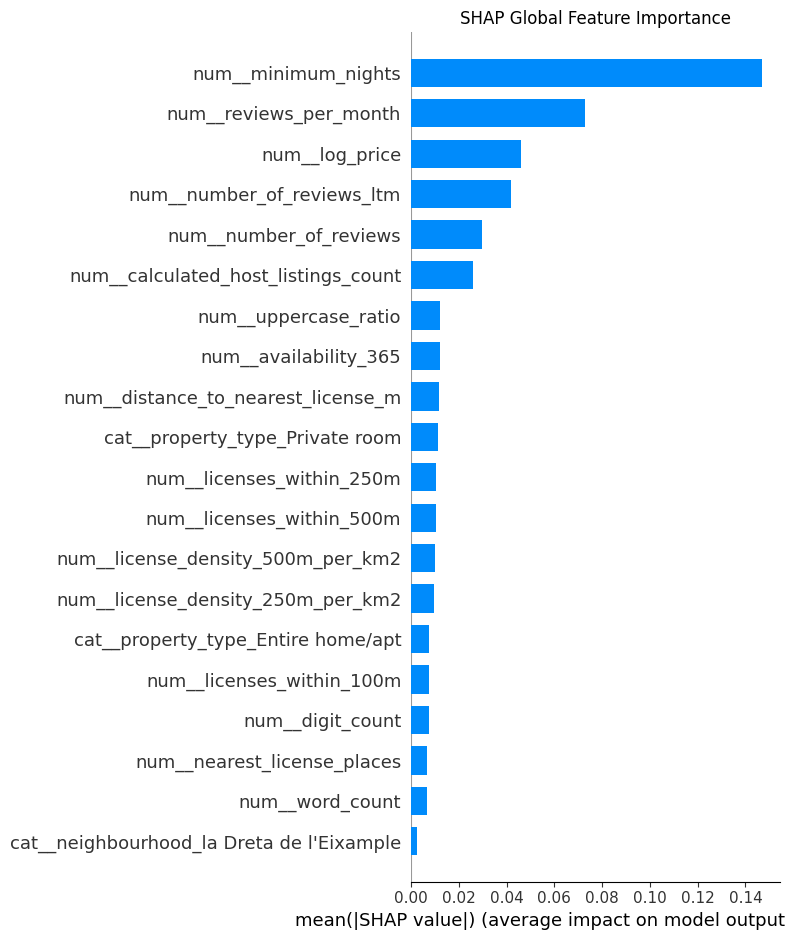

Saved: c:\Users\David\Documents\TFG\Fraudulent_property_listing_detection_tool\tool\reports\figures\shap_summary_bar.png


In [38]:
plt.figure()
shap.summary_plot(
    shap_values_positive,
    X_shap,
    plot_type="bar",
    max_display=20,
    show=False,
)
plt.title("SHAP Global Feature Importance")
plt.tight_layout()
plt.savefig(SHAP_BAR_FIG_PATH, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", SHAP_BAR_FIG_PATH)

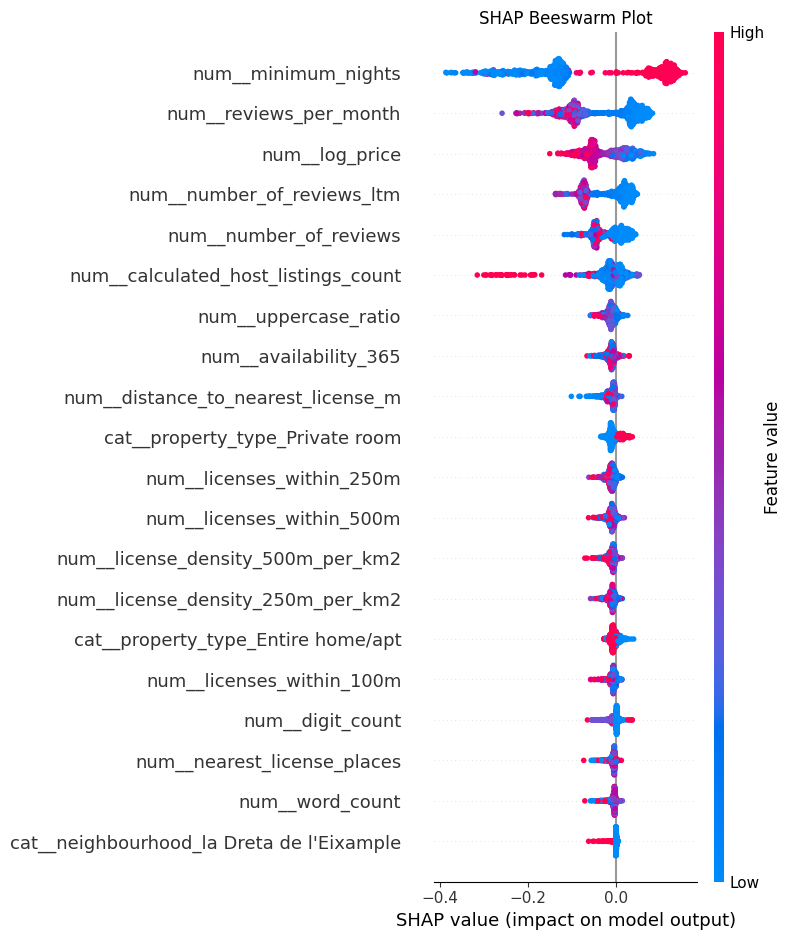

Saved: c:\Users\David\Documents\TFG\Fraudulent_property_listing_detection_tool\tool\reports\figures\shap_beeswarm.png


In [39]:
plt.figure()
shap.summary_plot(
    shap_values_positive,
    X_shap,
    max_display=20,
    show=False,
)
plt.title("SHAP Beeswarm Plot")
plt.tight_layout()
plt.savefig(SHAP_BEESWARM_FIG_PATH, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", SHAP_BEESWARM_FIG_PATH)

## Grouped SHAP importance by original feature

One-hot encoded categorical variables generate several transformed columns.

To make the results easier to interpret, transformed feature names are grouped back into their original feature families when possible. This gives a cleaner view of which original variables matter most.

In [40]:
def map_transformed_feature_to_original(feature_name):
    if feature_name.startswith("num__"):
        return feature_name.replace("num__", "")

    if feature_name.startswith("cat__property_type_"):
        return "property_type"

    if feature_name.startswith("cat__neighbourhood_"):
        return "neighbourhood"

    if feature_name.startswith("cat__"):
        return feature_name.replace("cat__", "").split("_")[0]

    return feature_name


shap_global_importance["original_feature"] = (
    shap_global_importance["feature"]
    .apply(map_transformed_feature_to_original)
)

grouped_shap_importance = (
    shap_global_importance
    .groupby("original_feature", as_index=False)
    .agg(mean_abs_shap=("mean_abs_shap", "sum"))
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

display(grouped_shap_importance.head(25))

GROUPED_SHAP_IMPORTANCE_PATH = TABLES_DIR / "shap_grouped_importance.csv"

grouped_shap_importance.to_csv(GROUPED_SHAP_IMPORTANCE_PATH, index=False)

print("Saved:", GROUPED_SHAP_IMPORTANCE_PATH)

,original_feature,mean_abs_shap
0,minimum_nights,0.147121
1,reviews_per_month,0.072899
2,log_price,0.045850
3,number_of_reviews_ltm,0.042073
4,number_of_reviews,0.029688
5,calculated_host_listings_count,0.025833
6,neighbourhood,0.022885
7,property_type,0.019247
8,uppercase_ratio,0.012258
9,availability_365,0.012110


Saved: c:\Users\David\Documents\TFG\Fraudulent_property_listing_detection_tool\tool\reports\tables\shap_grouped_importance.csv


,variable_group,total_mean_abs_shap,number_of_features,relative_importance
0,activity,0.329724,6,0.641371
1,geospatial,0.058413,9,0.113623
2,economic,0.045850,1,0.089187
3,categorical,0.042132,2,0.081954
4,textual,0.027759,4,0.053996
5,other,0.010215,1,0.019869


Saved: c:\Users\David\Documents\TFG\Fraudulent_property_listing_detection_tool\tool\reports\tables\appendix_shap_variable_group_importance.csv


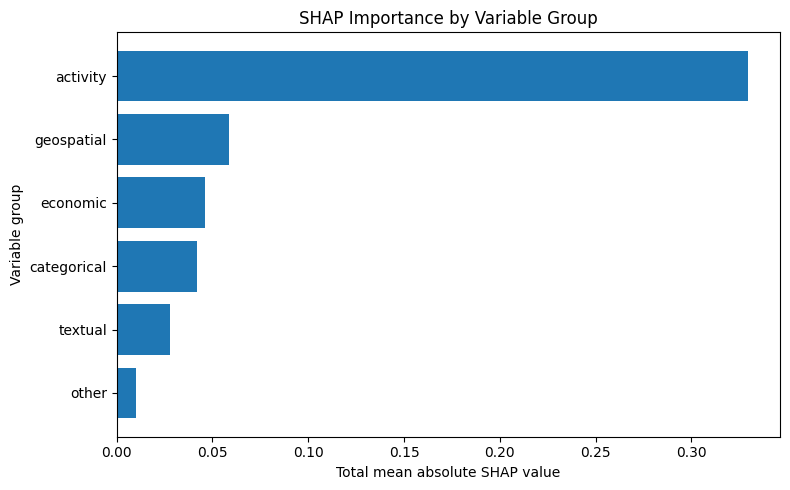

Saved: c:\Users\David\Documents\TFG\Fraudulent_property_listing_detection_tool\tool\reports\figures\appendix_shap_variable_group_importance.png


In [41]:
def assign_feature_group(original_feature):
    economic_features = {
        "price",
        "log_price",
    }

    activity_features = {
        "minimum_nights",
        "number_of_reviews",
        "number_of_reviews_ltm",
        "reviews_per_month",
        "availability_365",
        "calculated_host_listings_count",
    }

    textual_features_group = {
        "text_length",
        "word_count",
        "uppercase_ratio",
        "digit_count",
        "exclamation_count",
    }

    categorical_features_group = {
        "property_type",
        "neighbourhood",
    }

    geospatial_features = {
        "distance_to_nearest_license_m",
        "licenses_within_100m",
        "licenses_within_250m",
        "licenses_within_500m",
        "has_license_within_100m",
        "has_license_within_250m",
        "has_license_within_500m",
        "license_density_250m_per_km2",
        "nearest_license_places",
    }

    if original_feature in economic_features:
        return "economic"

    if original_feature in activity_features:
        return "activity"

    if original_feature in textual_features_group:
        return "textual"

    if original_feature in categorical_features_group:
        return "categorical"

    if original_feature in geospatial_features:
        return "geospatial"

    return "other"


grouped_shap_by_variable_group = grouped_shap_importance.copy()

grouped_shap_by_variable_group["variable_group"] = (
    grouped_shap_by_variable_group["original_feature"]
    .apply(assign_feature_group)
)

shap_variable_group_importance = (
    grouped_shap_by_variable_group
    .groupby("variable_group", as_index=False)
    .agg(
        total_mean_abs_shap=("mean_abs_shap", "sum"),
        number_of_features=("original_feature", "nunique"),
    )
    .sort_values("total_mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

shap_variable_group_importance["relative_importance"] = (
    shap_variable_group_importance["total_mean_abs_shap"]
    / shap_variable_group_importance["total_mean_abs_shap"].sum()
)

display(shap_variable_group_importance)

SHAP_VARIABLE_GROUP_IMPORTANCE_PATH = (
    TABLES_DIR / "appendix_shap_variable_group_importance.csv"
)

shap_variable_group_importance.to_csv(
    SHAP_VARIABLE_GROUP_IMPORTANCE_PATH,
    index=False,
)

print("Saved:", SHAP_VARIABLE_GROUP_IMPORTANCE_PATH)

# ------------------------------------------------------------
# Plot grouped SHAP importance
# ------------------------------------------------------------

SHAP_VARIABLE_GROUP_FIG_PATH = (
    FIGURES_DIR / "appendix_shap_variable_group_importance.png"
)

plot_df = shap_variable_group_importance.sort_values(
    "total_mean_abs_shap",
    ascending=True,
)

plt.figure(figsize=(8, 5))
plt.barh(
    plot_df["variable_group"],
    plot_df["total_mean_abs_shap"],
)

plt.xlabel("Total mean absolute SHAP value")
plt.ylabel("Variable group")
plt.title("SHAP Importance by Variable Group")
plt.tight_layout()
plt.savefig(SHAP_VARIABLE_GROUP_FIG_PATH, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", SHAP_VARIABLE_GROUP_FIG_PATH)

## Local SHAP explanations

Global SHAP explains which features are important overall.

Local SHAP explains individual predictions. This is useful for understanding why a specific listing receives a high or low risk score.

The following examples are selected:

- true positive with high risk score;
- true negative with low risk score;
- false positive;
- false negative.

These examples help interpret both correct predictions and model errors.

In [42]:
prediction_df["prediction_type"] = np.select(
    [
        (prediction_df["true_label"] == 1) & (prediction_df["binary_prediction"] == 1),
        (prediction_df["true_label"] == 0) & (prediction_df["binary_prediction"] == 0),
        (prediction_df["true_label"] == 0) & (prediction_df["binary_prediction"] == 1),
        (prediction_df["true_label"] == 1) & (prediction_df["binary_prediction"] == 0),
    ],
    [
        "true_positive",
        "true_negative",
        "false_positive",
        "false_negative",
    ],
    default="unknown",
)

local_example_indices = []

example_selection_rules = {
    "true_positive": ("risk_score", False),
    "true_negative": ("risk_score", True),
    "false_positive": ("risk_score", False),
    "false_negative": ("risk_score", True),
}

for prediction_type, (sort_col, ascending) in example_selection_rules.items():
    candidates = prediction_df[
        prediction_df["prediction_type"] == prediction_type
    ]

    if len(candidates) > 0:
        selected_index = (
            candidates
            .sort_values(sort_col, ascending=ascending)
            .index[0]
        )
        local_example_indices.append(selected_index)

local_examples = prediction_df.loc[local_example_indices].copy()

display(
    local_examples[
        [
            "true_label",
            "binary_prediction",
            "risk_score",
            "selected_threshold",
            "prediction_type",
        ]
    ]
)

,true_label,binary_prediction,risk_score,selected_threshold,prediction_type
2524,1,1,0.995,0.37,true_positive
48,0,0,0.000,0.37,true_negative
2456,0,1,0.885,0.37,false_positive
1655,1,0,0.000,0.37,false_negative


In [43]:
local_transformed = preprocessor.transform(X_test.loc[local_example_indices])

if hasattr(local_transformed, "toarray"):
    local_transformed = local_transformed.toarray()

local_transformed_df = pd.DataFrame(
    local_transformed,
    columns=feature_names,
    index=local_example_indices,
)

local_shap_raw = explainer.shap_values(local_transformed_df)

if isinstance(local_shap_raw, list):
    local_shap_values = local_shap_raw[1]
elif isinstance(local_shap_raw, np.ndarray) and local_shap_raw.ndim == 3:
    local_shap_values = local_shap_raw[:, :, 1]
else:
    local_shap_values = local_shap_raw

local_rows = []

for row_position, original_index in enumerate(local_example_indices):
    shap_row = local_shap_values[row_position]

    top_feature_positions = np.argsort(np.abs(shap_row))[::-1][:8]

    for feature_position in top_feature_positions:
        local_rows.append({
            "test_index": original_index,
            "prediction_type": prediction_df.loc[original_index, "prediction_type"],
            "true_label": prediction_df.loc[original_index, "true_label"],
            "binary_prediction": prediction_df.loc[original_index, "binary_prediction"],
            "risk_score": prediction_df.loc[original_index, "risk_score"],
            "feature": feature_names[feature_position],
            "feature_value": local_transformed_df.iloc[row_position, feature_position],
            "shap_value": shap_row[feature_position],
            "abs_shap_value": abs(shap_row[feature_position]),
        })

local_shap_examples = pd.DataFrame(local_rows)

display(local_shap_examples)

local_shap_examples.to_csv(SHAP_LOCAL_EXAMPLES_PATH, index=False)

print("Saved:", SHAP_LOCAL_EXAMPLES_PATH)

,test_index,prediction_type,true_label,binary_prediction,risk_score,feature,feature_value,shap_value,abs_shap_value
0,2524,true_positive,1,1,0.995,num__minimum_nights,0.692078,0.147290,0.147290
1,2524,true_positive,1,1,0.995,num__reviews_per_month,-0.661194,0.076514,0.076514
2,2524,true_positive,1,1,0.995,num__number_of_reviews,-0.518831,0.045575,0.045575
3,2524,true_positive,1,1,0.995,num__number_of_reviews_ltm,-0.555090,0.042755,0.042755
4,2524,true_positive,1,1,0.995,num__calculated_host_listings_count,1.412947,0.024934,0.024934
5,2524,true_positive,1,1,0.995,num__log_price,-0.151903,0.020216,0.020216
6,2524,true_positive,1,1,0.995,num__availability_365,1.254491,0.017025,0.017025
7,2524,true_positive,1,1,0.995,num__digit_count,-0.544410,0.013932,0.013932
8,48,true_negative,0,0,0.000,num__minimum_nights,-0.632532,-0.125320,0.125320
9,48,true_negative,0,0,0.000,num__reviews_per_month,1.064349,-0.090889,0.090889


Saved: c:\Users\David\Documents\TFG\Fraudulent_property_listing_detection_tool\tool\reports\tables\shap_local_examples.csv


## Error analysis

The error analysis compares true positives, true negatives, false positives and false negatives.

This helps identify whether model errors are associated with systematic patterns in risk score or selected input features.

This is descriptive analysis, not causal evidence.

In [44]:
error_analysis_features = [
    "risk_score",
    "log_price",
    "availability_365",
    "number_of_reviews",
    "reviews_per_month",
    "distance_to_nearest_license_m",
    "licenses_within_250m",
    "license_density_250m_per_km2",
]

available_error_features = [
    col for col in error_analysis_features
    if col in prediction_df.columns
]

error_analysis_summary = (
    prediction_df
    .groupby("prediction_type")[available_error_features]
    .mean()
    .reset_index()
)

error_counts = (
    prediction_df["prediction_type"]
    .value_counts()
    .rename_axis("prediction_type")
    .reset_index(name="count")
)

error_analysis_summary = error_analysis_summary.merge(
    error_counts,
    on="prediction_type",
    how="left",
)

display(error_analysis_summary)

error_analysis_summary.to_csv(ERROR_ANALYSIS_PATH, index=False)

print("Saved:", ERROR_ANALYSIS_PATH)

,prediction_type,risk_score,log_price,availability_365,number_of_reviews,reviews_per_month,distance_to_nearest_license_m,licenses_within_250m,license_density_250m_per_km2,count
0,false_negative,0.208163,4.649021,205.020408,59.775510,0.770000,63.778125,44.244898,225.337415,98
1,false_positive,0.535996,4.300931,234.911032,5.199288,0.171281,54.527083,46.103203,234.801684,281
2,true_negative,0.057939,5.110420,225.981132,85.786164,1.823846,43.924118,60.830672,309.808071,2067
3,true_positive,0.637340,4.239414,237.095238,5.118227,0.128785,62.749001,44.041051,224.299230,609


Saved: c:\Users\David\Documents\TFG\Fraudulent_property_listing_detection_tool\tool\reports\tables\final_error_analysis_summary.csv


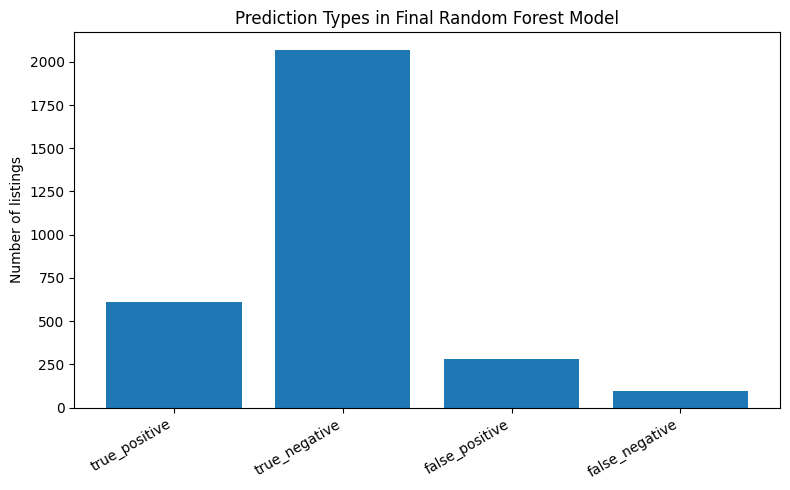

Saved: c:\Users\David\Documents\TFG\Fraudulent_property_listing_detection_tool\tool\reports\figures\final_error_analysis.png


In [45]:
error_counts_plot = (
    prediction_df["prediction_type"]
    .value_counts()
    .reindex(["true_positive", "true_negative", "false_positive", "false_negative"])
)

plt.figure(figsize=(8, 5))
plt.bar(error_counts_plot.index, error_counts_plot.values)
plt.xticks(rotation=30, ha="right")
plt.ylabel("Number of listings")
plt.title("Prediction Types in Final Random Forest Model")
plt.tight_layout()
plt.savefig(ERROR_ANALYSIS_FIG_PATH, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", ERROR_ANALYSIS_FIG_PATH)